# Import modules

In [1]:
import os
import sys

project_root = os.path.abspath("..") 
if project_root not in sys.path:
    sys.path.append(project_root)

# XGBoost

LOADING AND SPLITTING DATA


d:\Study\VPBank_Hackathon_25\src\pipeline2\XGBoost.py:83: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path)


Raw data loaded: (100000, 28)
After dropping personal info: (100000, 21)
Train data: (80000, 21)
Test data: (20000, 21)

PREPROCESSING TRAINING DATA
Training data after pipeline: (80000, 37)
Handling negative values...
Total negative values converted: 0
Handling missing values with intelligent strategy...
  Monthly_Inhand_Salary: 12032 missing -> median (3191104166666666.0000) (skewed: 2.60)
  Num_of_Delayed_Payment: 5595 missing -> median (14.0000) (skewed: 14.21)
  Changed_Credit_Limit: 1691 missing -> median (902.0000) (skewed: 10.44)
  Num_Credit_Inquiries: 1549 missing -> median (60.0000) (skewed: 9.69)
  Credit_History_Age: 7240 missing -> mean (18.4345) (normal dist)
  Amount_invested_monthly: 3605 missing -> median (8131127094677352.0000) (skewed: 1.77)
  Monthly_Balance: 950 missing -> median (6580492431588418.0000) (skewed: 106.26)
Converting object columns to numeric...
Training features: (80000, 36)
Training target distribution: {0: 14262, 1: 23199, 2: 42539}

SCALING AND O

c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Test data after pipeline: (20000, 37)
Applying consistent missing value strategy...
  Monthly_Inhand_Salary: 2970 missing -> 3191104166666666.0 (median_skewed)
  Num_of_Delayed_Payment: 1407 missing -> 14.0 (median_skewed)
  Changed_Credit_Limit: 400 missing -> 902.0 (median_skewed)
  Num_Credit_Inquiries: 416 missing -> 60.0 (median_skewed)
  Credit_History_Age: 1790 missing -> 18.43452331867326 (mean_normal)
  Amount_invested_monthly: 874 missing -> 8131127094677352.0 (median_skewed)
  Monthly_Balance: 250 missing -> 6580492431588418.0 (median_skewed)
Scaling disabled for test data
Test features: (20000, 36)
Test target distribution: {0: 3566, 1: 5799, 2: 10635}

TRAINING XGBOOST MODEL
Training XGBoost...
Training completed!

MODEL EVALUATION
Test Accuracy: 0.7904

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74      3566
           1       0.79      0.78      0.79      5799
           2       0.80      0.82   

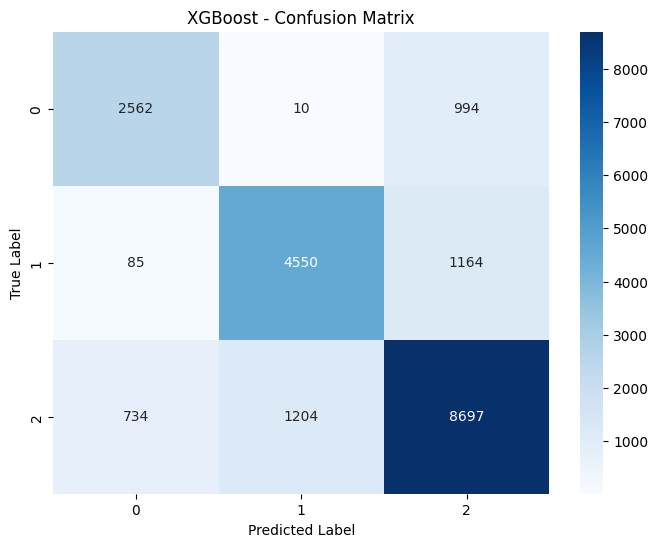


SAVING MODEL AND COMPONENTS
Preprocessing pipeline saved to: ..\models\xgboost_preprocessing_pipeline.pkl
XGBoost model saved to: ..\models\xgboost_model.pkl
Scaler saved to: ..\models\xgboost_scaler.pkl
Model info saved to: ..\models\xgboost_model_info.pkl


In [2]:
from src.pipeline2.XGBoost import *

# 1. Load and split data FIRST
train_data, test_data = load_and_split_data()

# 2. Create pipeline
pipeline = create_preprocessing_pipeline()

# 3. Fit pipeline on train data only
X_train, y_train, missing_fill_strategy = preprocess_training_data(train_data, pipeline)

# 4. Scale based on training data
X_train_scaled, scaler, bounds, numeric_features = scale_and_handle_outliers(X_train)

# 5. Apply fitted pipeline and scaler to test data
X_test_scaled, y_test = preprocess_test_data(test_data, pipeline, scaler, bounds, numeric_features, missing_fill_strategy=missing_fill_strategy)

# 6. Train model
model = train_xgboost_model(X_train, y_train)

# 7. Evaluate
accuracy = evaluate_model(model, X_test_scaled, y_test)

# 8. Save everything
model_path, pipeline_path, scaler_path, info_path = save_model_and_pipeline(model, pipeline, scaler, bounds, numeric_features, importance_df=None, accuracy=accuracy, missing_fill_strategy=missing_fill_strategy)

In [3]:
new_data_path = os.path.join(
        "..",
        "data",
        "kaggle_credit_score_classification",
        "test.csv",
    )

In [4]:
predict_new_data(new_data_path, model_path, pipeline_path, scaler_path, info_path)


MAKING PREDICTIONS ON NEW DATA
All components loaded successfully!
New data loaded: (50000, 27)


c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Applied median_skewed strategy to Monthly_Inhand_Salary: 7498 missing -> 3191104166666666.0
Applied median_skewed strategy to Num_of_Delayed_Payment: 3498 missing -> 14.0
Applied median_skewed strategy to Changed_Credit_Limit: 1059 missing -> 902.0
Applied median_skewed strategy to Num_Credit_Inquiries: 1035 missing -> 60.0
Applied mean_normal strategy to Credit_History_Age: 4470 missing -> 18.43452331867326
Applied median_skewed strategy to Amount_invested_monthly: 2271 missing -> 8131127094677352.0
Applied median_skewed strategy to Monthly_Balance: 562 missing -> 6580492431588418.0
Predictions made for 50000 samples
Prediction distribution: {0: 8488, 1: 14485, 2: 27027}


(array([0, 0, 0, ..., 1, 1, 1], shape=(50000,)),
 array([[0.77069414, 0.05018468, 0.17912118],
        [0.8370091 , 0.02919665, 0.1337943 ],
        [0.7467106 , 0.03542705, 0.21786235],
        ...,
        [0.08030573, 0.57292354, 0.34677073],
        [0.12263427, 0.5849289 , 0.29243687],
        [0.05313496, 0.5222684 , 0.42459664]],
       shape=(50000, 3), dtype=float32))